In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the original Excel file
file_path = 'clustering.xlsx'  # Replace with the actual path
data = pd.read_excel(file_path, sheet_name='Sheet1')



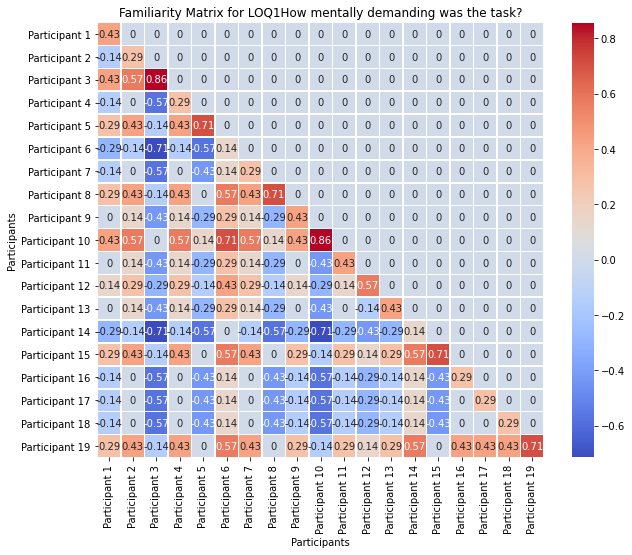

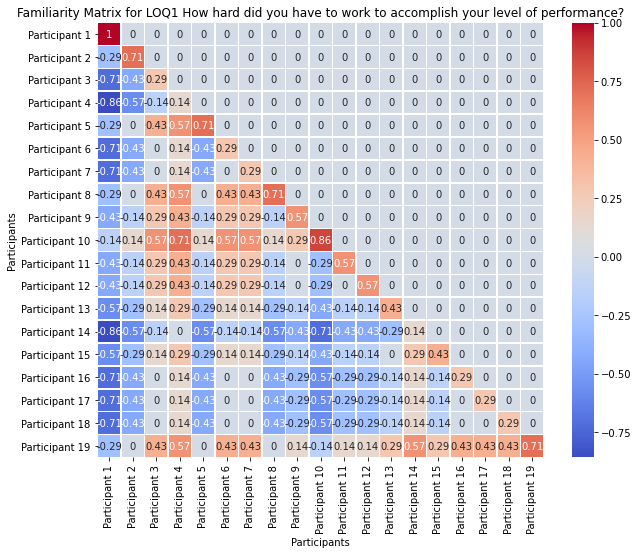

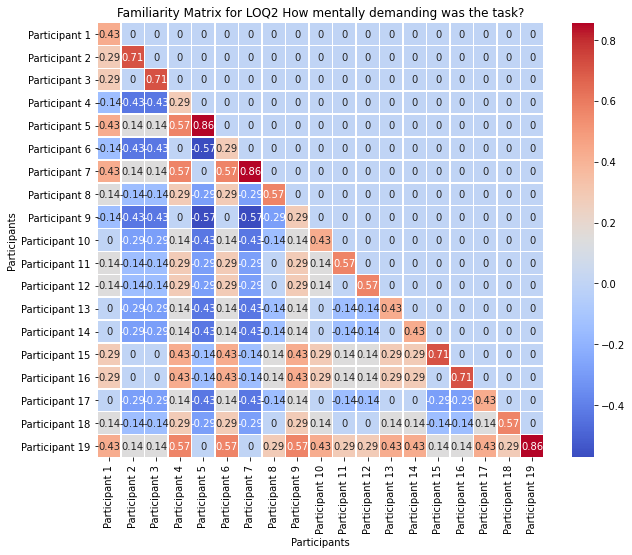

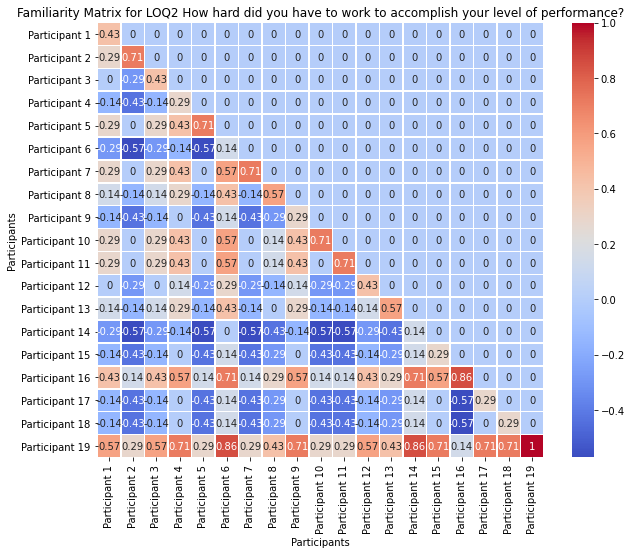

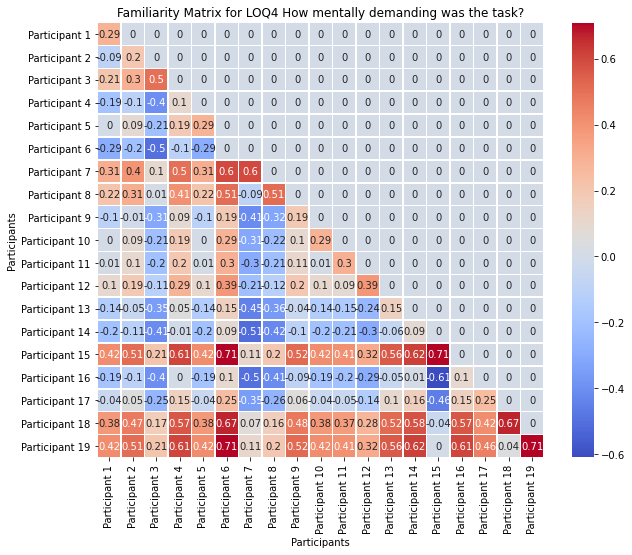

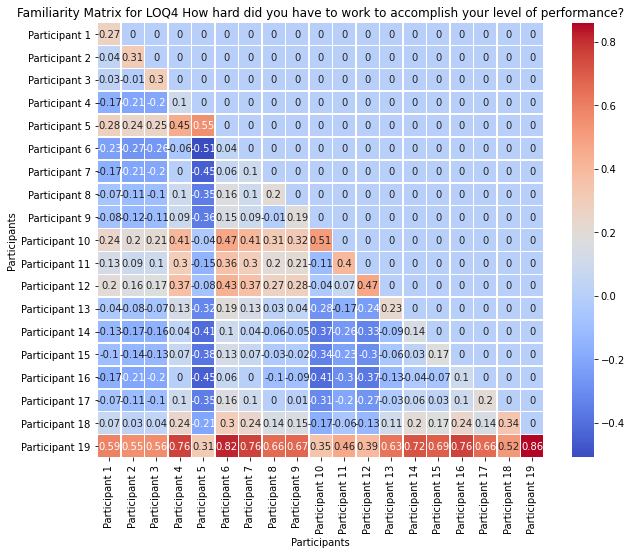

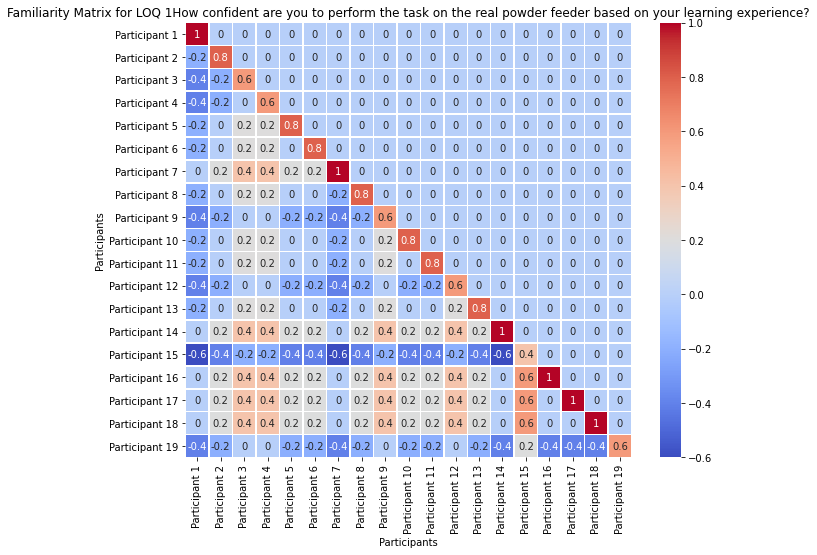

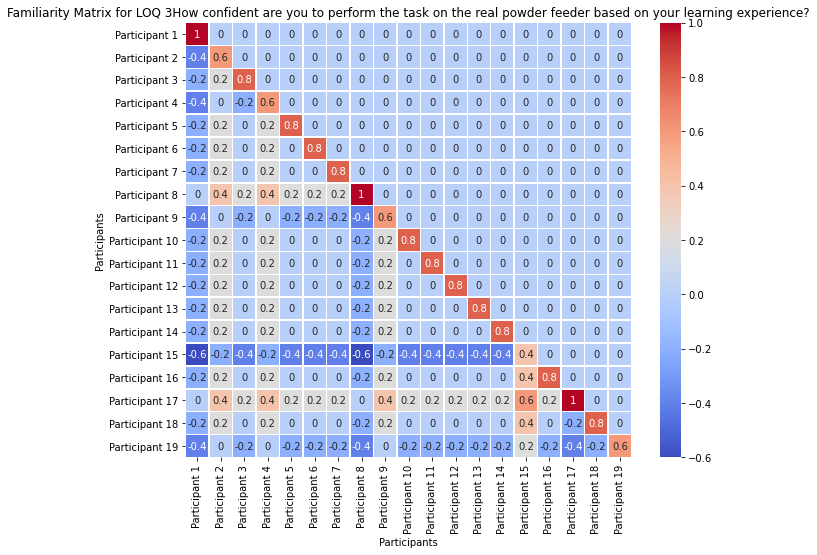

In [2]:


# List of columns for which we want to generate familiarity matrices
relevant_columns = [
    'LOQ1How mentally demanding was the task?',
    'LOQ1 How hard did you have to work to accomplish your level of performance?',
    'LOQ2 How mentally demanding was the task?',
    'LOQ2 How hard did you have to work to accomplish your level of performance?',
    'LOQ4 How mentally demanding was the task?',
    'LOQ4 How hard did you have to work to accomplish your level of performance?',
    'LOQ 1How confident are you to perform the task on the real powder feeder based on your learning experience?',
    'LOQ 3How confident are you to perform the task on the real powder feeder based on your learning experience?'
]

# Loop through each relevant column and create a familiarity matrix
for col in relevant_columns:
    # Extract the participant scores for the current column
    participant_scores = data[col].values

    # Initialize the familiarity matrix (zeroes initially)
    num_participants = len(participant_scores)
    familiarity_matrix = np.zeros((num_participants, num_participants))

    # Fill in the diagonal and below diagonal with differences (non-absolute)
    for i in range(num_participants):
        for j in range(i + 1):
            if i == j:
                familiarity_matrix[i, j] = participant_scores[i]  # Diagonal: participant's own score
            else:
                familiarity_matrix[i, j] = participant_scores[i] - participant_scores[j]  # Difference between participants

    # Convert matrix to a DataFrame for better visualization
    familiarity_matrix_df = pd.DataFrame(familiarity_matrix, 
                                         columns=[f'Participant {i+1}' for i in range(num_participants)],
                                         index=[f'Participant {i+1}' for i in range(num_participants)])

    # Create a heatmap for the familiarity matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(familiarity_matrix_df, annot=True, cmap='coolwarm', linewidths=0.5, cbar=True)
    plt.title(f'Familiarity Matrix for {col}')
    plt.xlabel('Participants')
    plt.ylabel('Participants')
    plt.show()


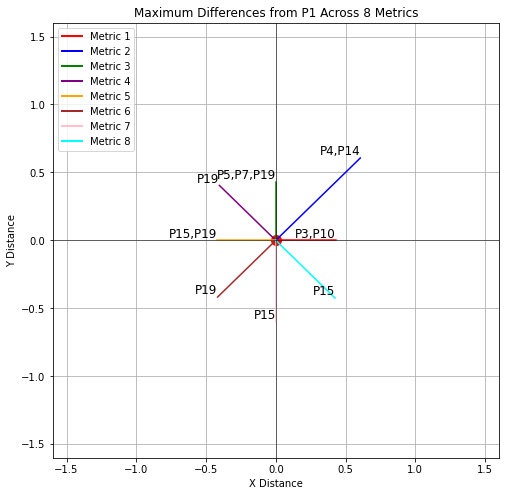

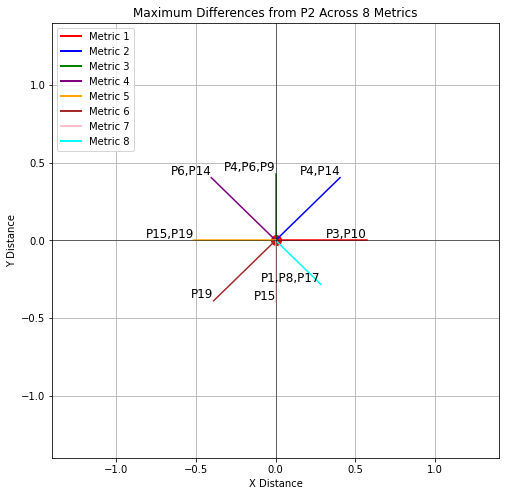

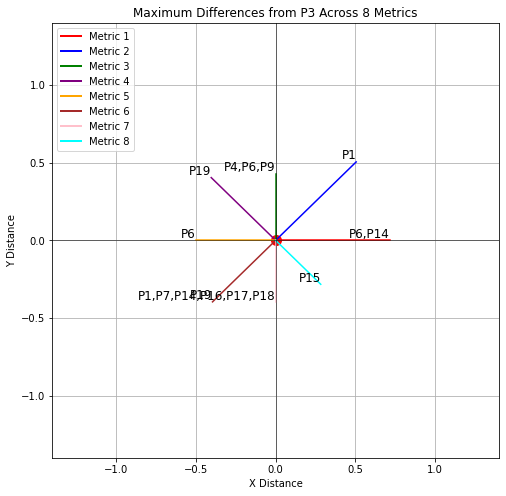

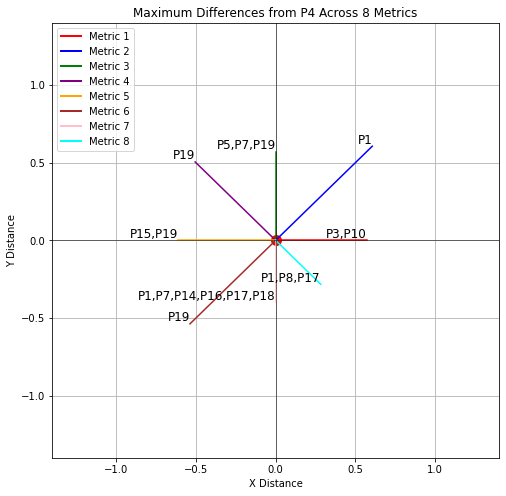

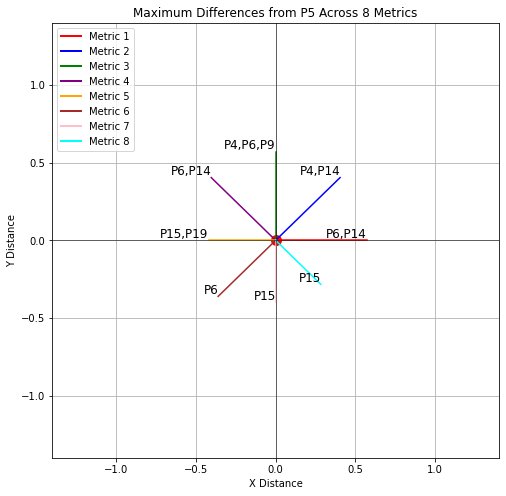

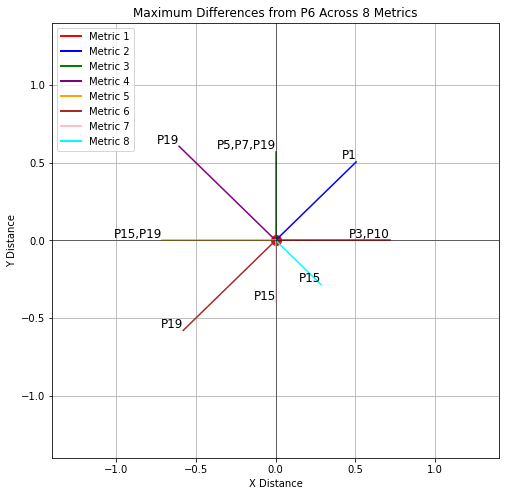

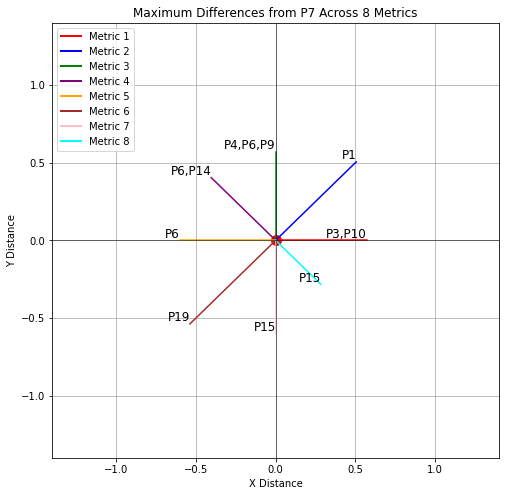

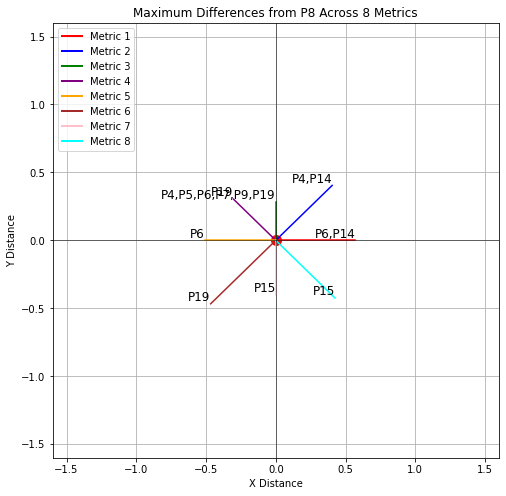

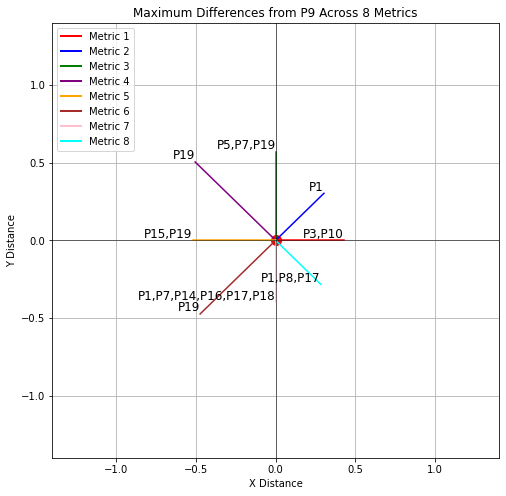

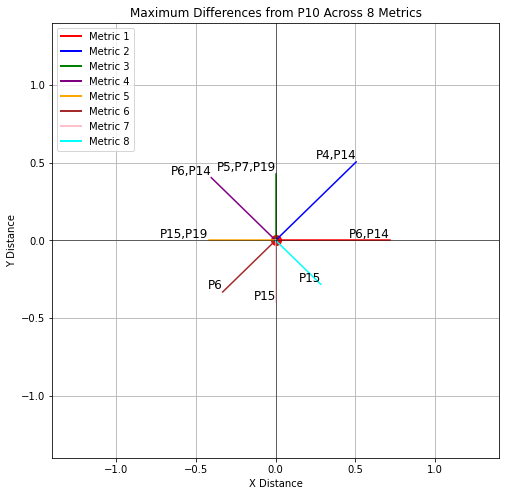

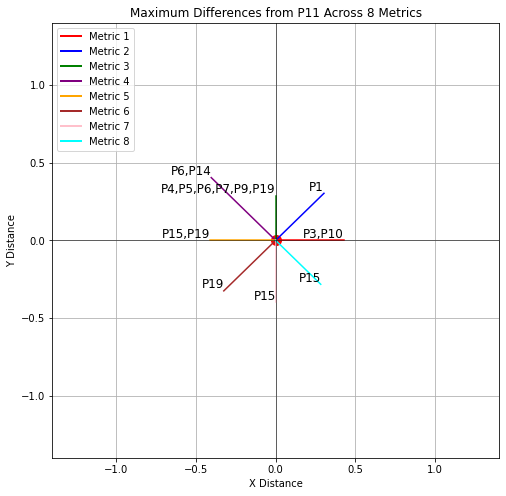

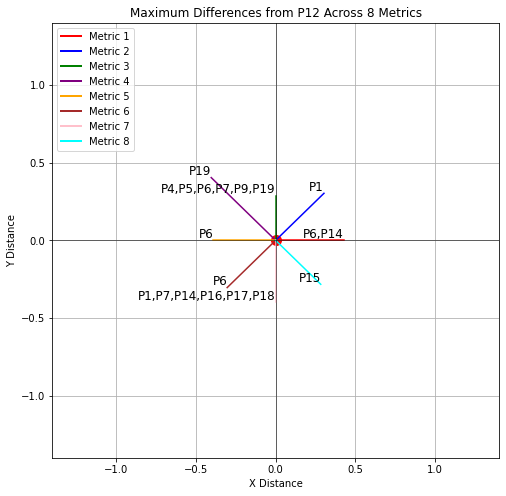

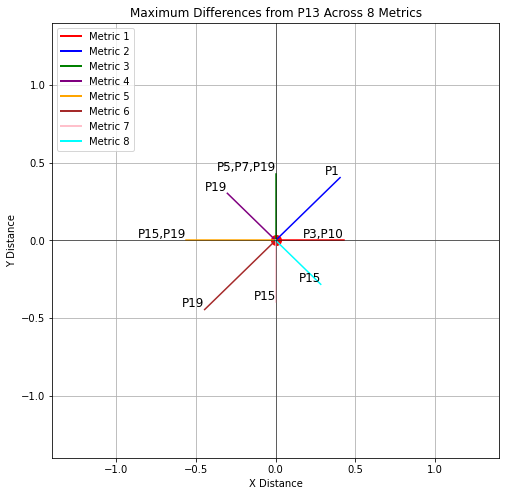

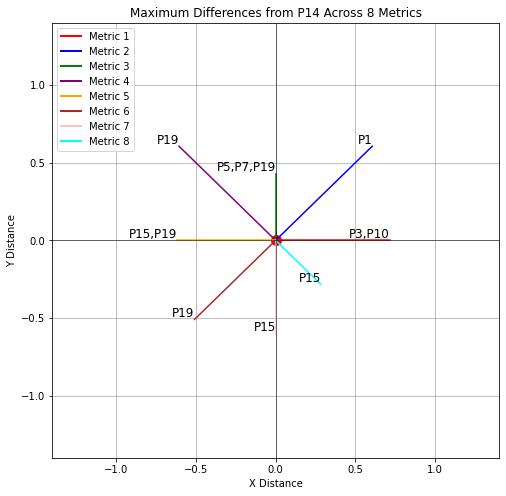

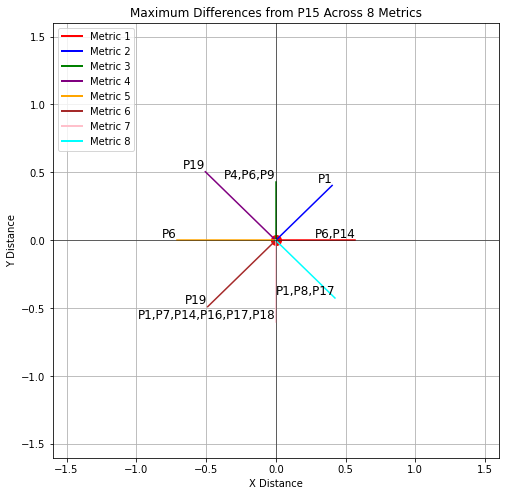

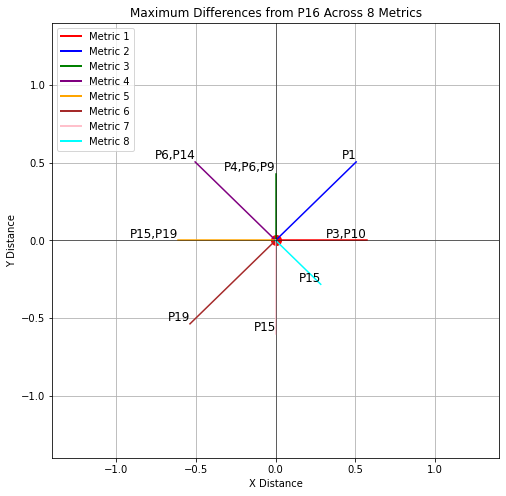

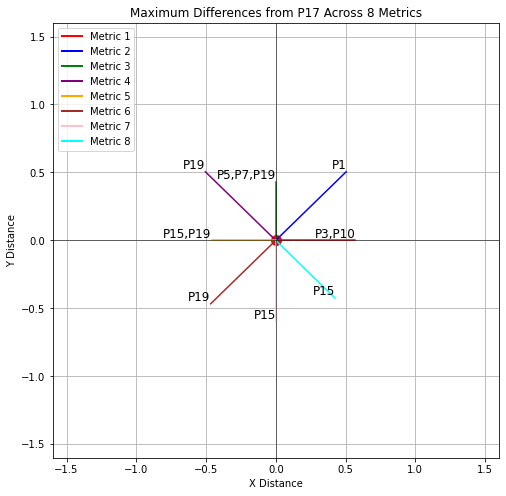

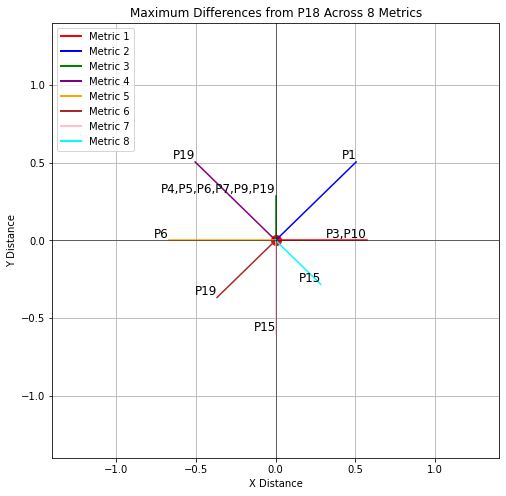

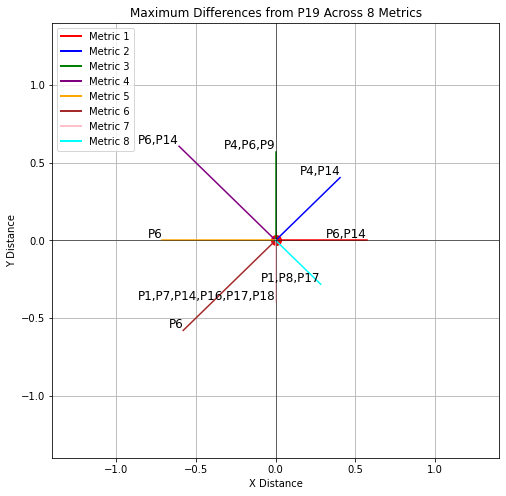


For P1:
  Most frequent farthest participants: P19 (appeared 4 times)
  Participants who did not appear: P1, P2, P6, P8, P9, P11, P12, P13, P16, P17, P18

For P2:
  Most frequent farthest participants: P4, P14, P6, P15, P19 (appeared 2 times)
  Participants who did not appear: P2, P5, P7, P11, P12, P13, P16, P18

For P3:
  Most frequent farthest participants: P6 (appeared 3 times)
  Participants who did not appear: P2, P3, P5, P8, P10, P11, P12, P13

For P4:
  Most frequent farthest participants: P19 (appeared 4 times)
  Participants who did not appear: P2, P4, P6, P9, P11, P12, P13

For P5:
  Most frequent farthest participants: P6 (appeared 4 times)
  Participants who did not appear: P1, P2, P3, P5, P7, P8, P10, P11, P12, P13, P16, P17, P18

For P6:
  Most frequent farthest participants: P19 (appeared 4 times)
  Participants who did not appear: P2, P4, P6, P8, P9, P11, P12, P13, P14, P16, P17, P18

For P7:
  Most frequent farthest participants: P6 (appeared 3 times)
  Participants w

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# List of columns/metrics
relevant_columns = [
    'LOQ1How mentally demanding was the task?',
    'LOQ1 How hard did you have to work to accomplish your level of performance?',
    'LOQ2 How mentally demanding was the task?',
    'LOQ2 How hard did you have to work to accomplish your level of performance?',
    'LOQ4 How mentally demanding was the task?',
    'LOQ4 How hard did you have to work to accomplish your level of performance?',
    'LOQ 1How confident are you to perform the task on the real powder feeder based on your learning experience?',
    'LOQ 3How confident are you to perform the task on the real powder feeder based on your learning experience?'
]

# Colors for each metric
metric_colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'cyan']

# Dictionary to track how many times each participant shows up as the farthest in each graph
participant_count_in_graph = defaultdict(lambda: defaultdict(int))

# Track total number of times each participant appears across all graphs
total_appearance_count = defaultdict(int)

# Set up data (assuming your data is loaded into a DataFrame named `data`)
# For scaling, let's do this for all participants

def plot_max_distances(Pn_index, data, relevant_columns):
    plt.figure(figsize=(8, 8))
    ax = plt.gca()

    # Place Pn (Participant n) at the origin
    Pn = (0, 0)
    plt.scatter(*Pn, color='red', s=100, label=f'P{Pn_index+1} (Origin)')
    
    # Angle to distribute lines evenly around Pn
    angles = np.linspace(0, 2 * np.pi, len(relevant_columns), endpoint=False)
    
    for i, (col, color) in enumerate(zip(relevant_columns, metric_colors)):
        # Calculate absolute differences from Pn
        differences = np.abs(data[col].values - data[col].values[Pn_index])
        
        # Ensure Pn's difference with itself is not considered
        differences[Pn_index] = np.nan
        
        # Maximum difference
        max_distance = np.nanmax(differences)
        
        # Participants with the maximum difference
        max_participants_indices = np.where(differences == max_distance)[0]
        
        # Track how many times each participant appears in this graph
        for idx in max_participants_indices:
            participant_count_in_graph[f'P{Pn_index+1}'][f'P{idx+1}'] += 1
            total_appearance_count[f'P{idx+1}'] += 1
        
        # Coordinates for the line end
        x, y = Pn[0] + max_distance * np.cos(angles[i]), Pn[1] + max_distance * np.sin(angles[i])
        
        # Draw line for each metric with its own color
        ax.add_line(plt.Line2D([Pn[0], x], [Pn[1], y], color=color, label=f'Metric {i+1}'))
        
        # Combine participant numbers into a single string
        participants_label = ','.join([f'P{idx+1}' for idx in max_participants_indices])
        
        # Plot a combined label at the end of the line
        plt.text(x, y, f'{participants_label}', fontsize=12, verticalalignment='bottom', horizontalalignment='right')

    # Set limits and labels
    plt.xlim(-max_distance - 1, max_distance + 1)
    plt.ylim(-max_distance - 1, max_distance + 1)
    plt.xlabel('X Distance')
    plt.ylabel('Y Distance')
    plt.title(f'Maximum Differences from P{Pn_index+1} Across 8 Metrics')

    # Create a legend for the metrics
    legend_handles = [plt.Line2D([0], [0], color=metric_colors[i], lw=2, label=f'Metric {i+1}') for i in range(len(relevant_columns))]
    ax.legend(handles=legend_handles, loc='upper left')

    plt.grid(True)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.show()

# Loop through all participants and track who appears in each graph
def plot_all_participants_and_track(data, relevant_columns):
    # Loop through all participants (e.g., P1 to P19)
    for Pn_index in range(len(data)):  # Assuming there are 19 participants
        plot_max_distances(Pn_index, data, relevant_columns)

# Test: plot all participants and track who appears at the farthest point
plot_all_participants_and_track(data, relevant_columns)

# Output Results

# Show how many times each participant appears in each graph (Pn's graph)
for graph, counts in participant_count_in_graph.items():
    # Find the most frequent participants in this graph
    if counts:
        max_count = max(counts.values())
        most_frequent_participants = [p for p, count in counts.items() if count == max_count]
        
        # Find participants who did not appear at all in this graph
        non_appearing_participants = [f'P{i}' for i in range(1, len(data)+1) if f'P{i}' not in counts]
        
        # Output the results for each graph
        print(f"\nFor {graph}:")
        print(f"  Most frequent farthest participants: {', '.join(most_frequent_participants)} (appeared {max_count} times)")
        if non_appearing_participants:
            print(f"  Participants who did not appear: {', '.join(non_appearing_participants)}")
    else:
        print(f"\nFor {graph}: No participants found.")

# Find and print the participant who appeared the most and the least across all graphs
most_frequent_participant = max(total_appearance_count, key=total_appearance_count.get)
least_frequent_participant = min(total_appearance_count, key=total_appearance_count.get)




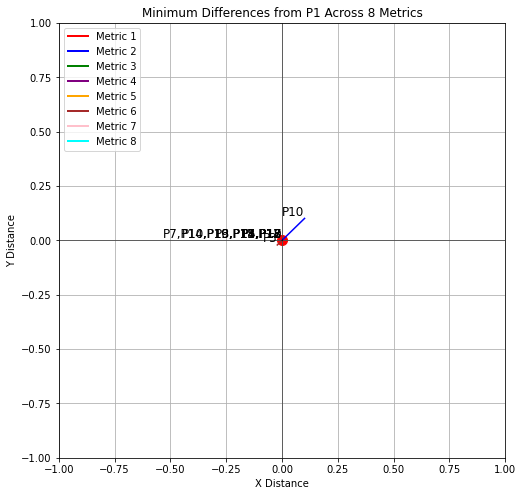

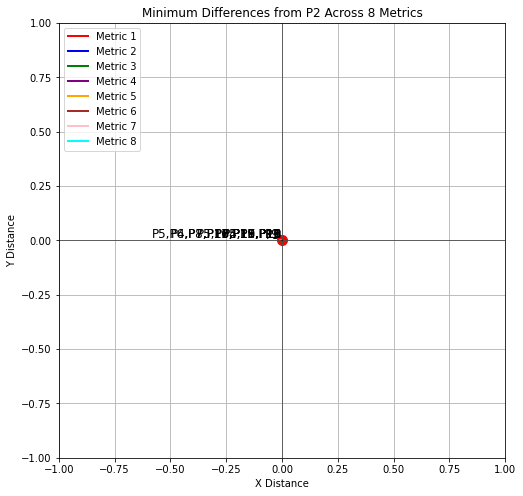

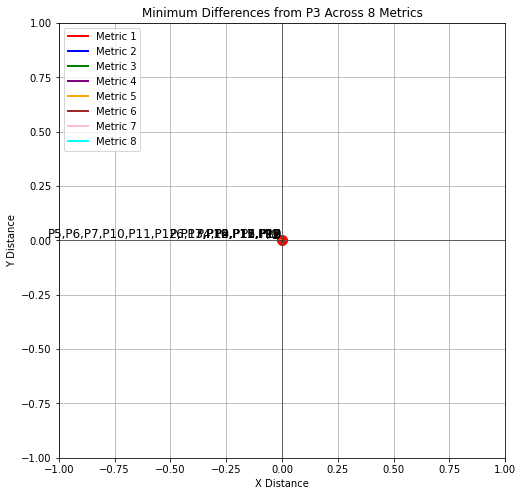

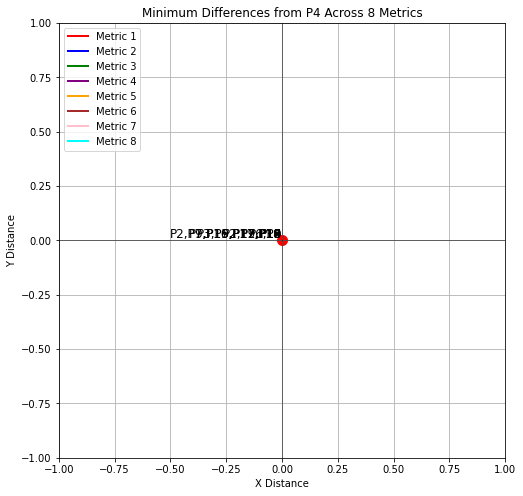

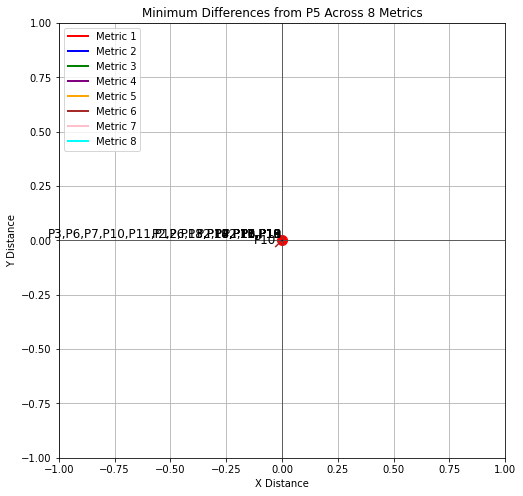

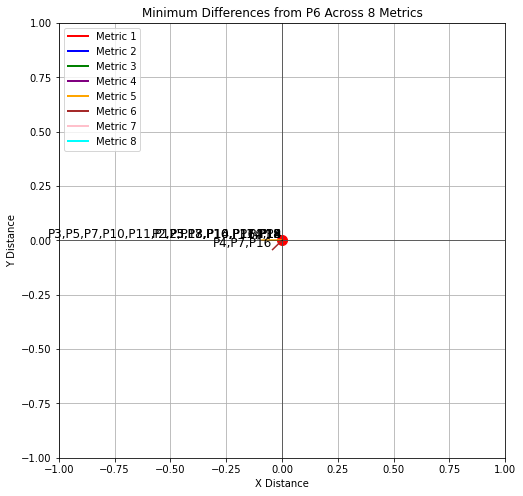

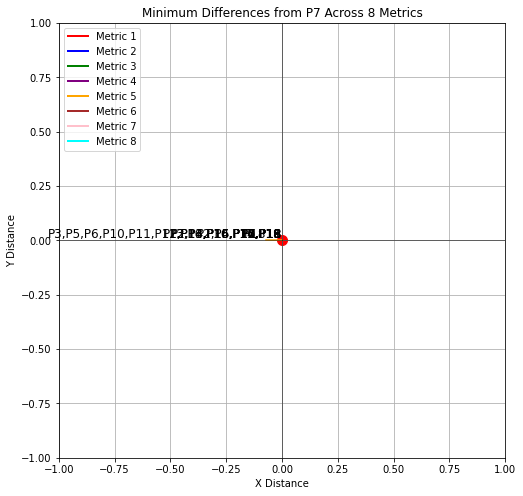

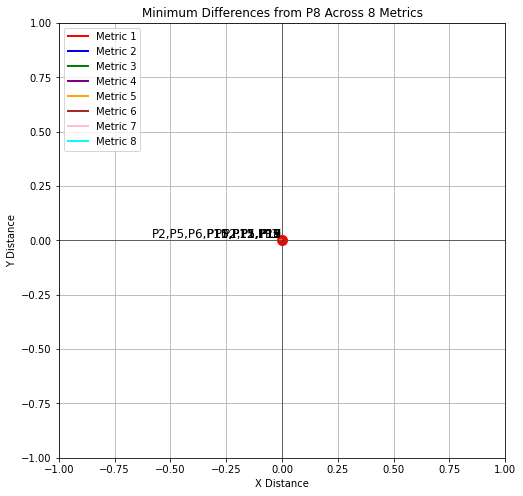

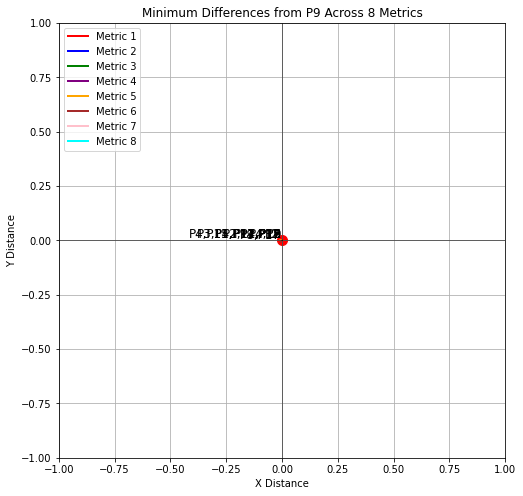

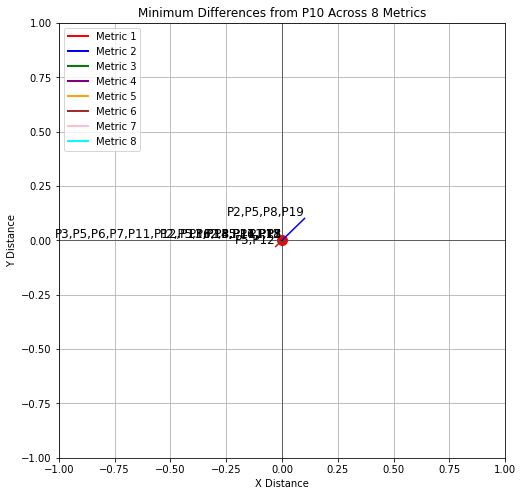

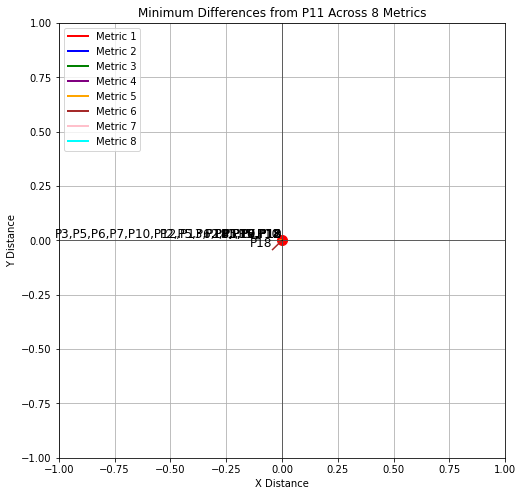

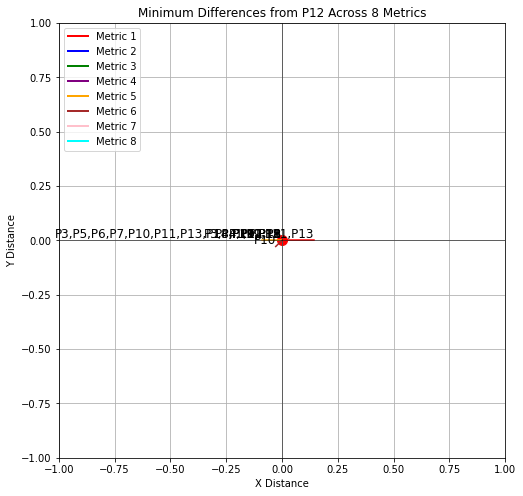

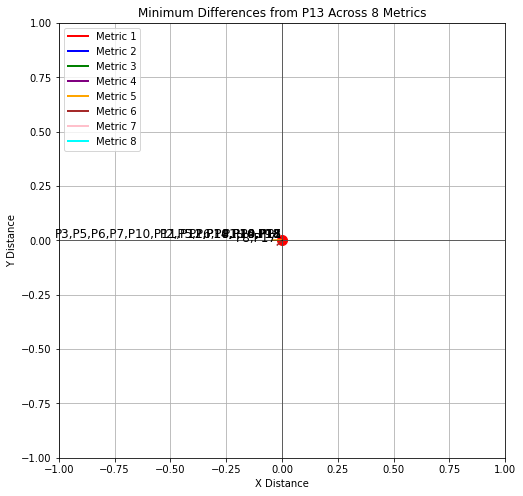

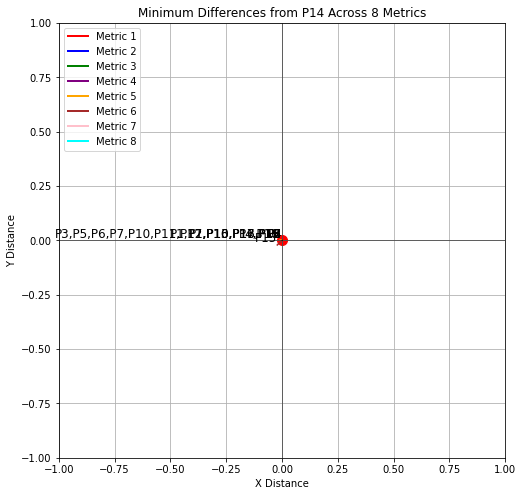

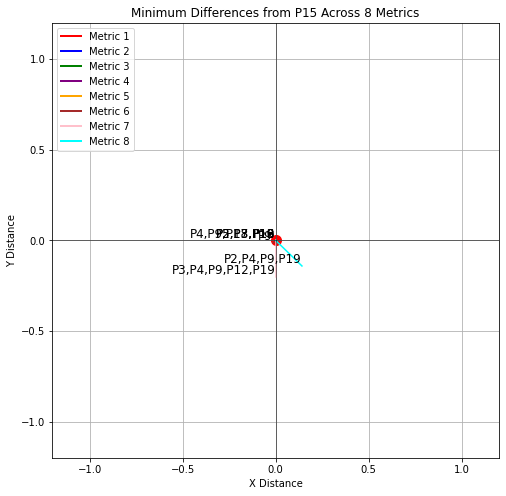

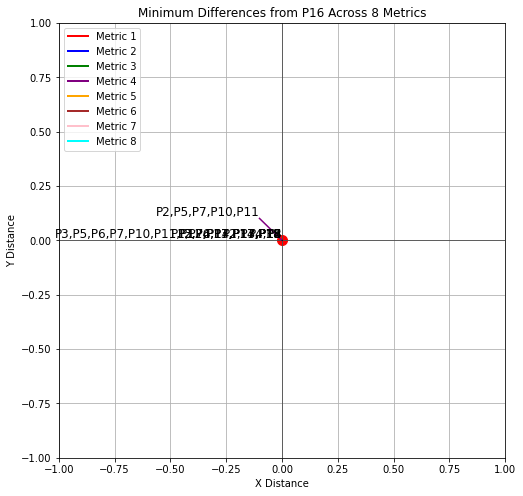

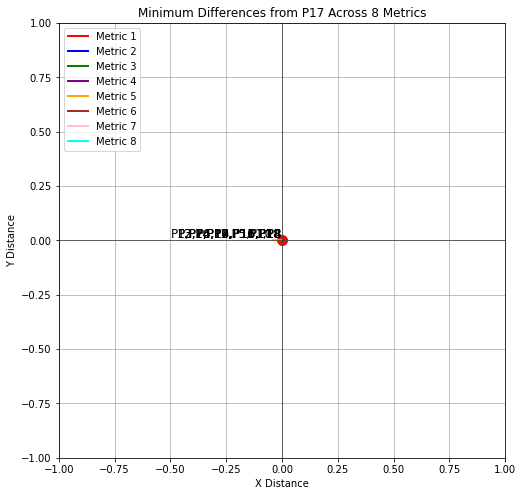

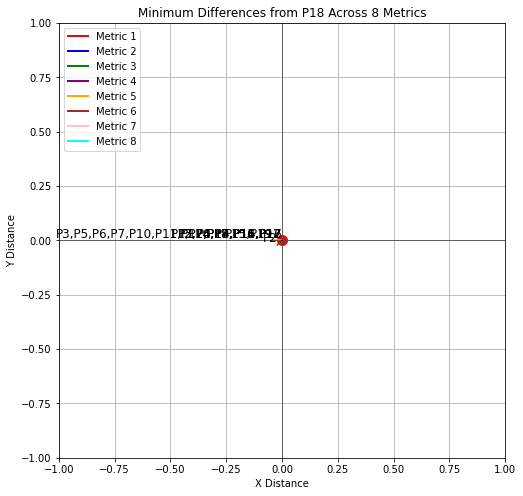

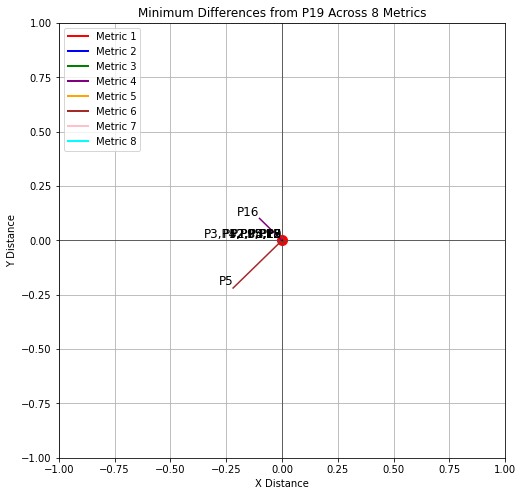


For P1:
  Most frequent closest participants: P10, P17 (appeared 3 times)
  Participants who did not appear: P1, P2, P4, P6, P15, P19

For P2:
  Most frequent closest participants: P5 (appeared 3 times)
  Participants who did not appear: P1, P2, P12, P14

For P3:
  Most frequent closest participants: P16, P12 (appeared 3 times)
  Participants who did not appear: P3

For P4:
  Most frequent closest participants: P9 (appeared 4 times)
  Participants who did not appear: P1, P4, P5, P8, P10, P11, P13

For P5:
  Most frequent closest participants: P10 (appeared 5 times)
  Participants who did not appear: P4, P5, P9, P17

For P6:
  Most frequent closest participants: P14 (appeared 4 times)
  Participants who did not appear: P1, P6, P15, P19

For P7:
  Most frequent closest participants: P16, P18 (appeared 5 times)
  Participants who did not appear: P7, P8, P9, P15

For P8:
  Most frequent closest participants: P5 (appeared 3 times)
  Participants who did not appear: P4, P7, P8, P9, P14, P16

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# List of columns/metrics
relevant_columns = [
    'LOQ1How mentally demanding was the task?',
    'LOQ1 How hard did you have to work to accomplish your level of performance?',
    'LOQ2 How mentally demanding was the task?',
    'LOQ2 How hard did you have to work to accomplish your level of performance?',
    'LOQ4 How mentally demanding was the task?',
    'LOQ4 How hard did you have to work to accomplish your level of performance?',
    'LOQ 1How confident are you to perform the task on the real powder feeder based on your learning experience?',
    'LOQ 3How confident are you to perform the task on the real powder feeder based on your learning experience?'
]

# Colors for each metric
metric_colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'cyan']

# Dictionary to track how many times each participant shows up as the closest (minimum distance) in each graph
participant_min_count_in_graph = defaultdict(lambda: defaultdict(int))

# Track total number of times each participant appears as the closest across all graphs
total_min_appearance_count = defaultdict(int)

# Set up data (assuming your data is loaded into a DataFrame named `data`)
# For scaling, let's do this for all participants

def plot_min_distances(Pn_index, data, relevant_columns):
    plt.figure(figsize=(8, 8))
    ax = plt.gca()

    # Place Pn (Participant n) at the origin
    Pn = (0, 0)
    plt.scatter(*Pn, color='red', s=100, label=f'P{Pn_index+1} (Origin)')
    
    # Angle to distribute lines evenly around Pn
    angles = np.linspace(0, 2 * np.pi, len(relevant_columns), endpoint=False)
    
    for i, (col, color) in enumerate(zip(relevant_columns, metric_colors)):
        # Calculate absolute differences from Pn
        differences = np.abs(data[col].values - data[col].values[Pn_index])
        
        # Exclude self-comparison (Pn compared to itself)
        differences[Pn_index] = np.nan
        
        # Minimum distance (including 0, but not self-comparison)
        min_distance = np.nanmin(differences)
        
        # Participants with the minimum difference
        min_participants_indices = np.where(differences == min_distance)[0]
        
        # Track how many times each participant appears in this graph for minimum distances
        for idx in min_participants_indices:
            participant_min_count_in_graph[f'P{Pn_index+1}'][f'P{idx+1}'] += 1
            total_min_appearance_count[f'P{idx+1}'] += 1
        
        # Coordinates for the line end
        x, y = Pn[0] + min_distance * np.cos(angles[i]), Pn[1] + min_distance * np.sin(angles[i])
        
        # Draw line for each metric with its own color
        ax.add_line(plt.Line2D([Pn[0], x], [Pn[1], y], color=color, label=f'Metric {i+1}'))
        
        # Combine participant numbers into a single string
        participants_label = ','.join([f'P{idx+1}' for idx in min_participants_indices])
        
        # Plot a combined label at the end of the line
        plt.text(x, y, f'{participants_label}', fontsize=12, verticalalignment='bottom', horizontalalignment='right')

    # Set limits and labels
    plt.xlim(-min_distance - 1, min_distance + 1)
    plt.ylim(-min_distance - 1, min_distance + 1)
    plt.xlabel('X Distance')
    plt.ylabel('Y Distance')
    plt.title(f'Minimum Differences from P{Pn_index+1} Across 8 Metrics')

    # Create a legend for the metrics
    legend_handles = [plt.Line2D([0], [0], color=metric_colors[i], lw=2, label=f'Metric {i+1}') for i in range(len(relevant_columns))]
    ax.legend(handles=legend_handles, loc='upper left')

    plt.grid(True)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.show()

# Loop through all participants and track who appears at minimum distance in each graph
def plot_all_participants_min_and_track(data, relevant_columns):
    # Loop through all participants (e.g., P1 to P19)
    for Pn_index in range(len(data)):  # Assuming there are 19 participants
        plot_min_distances(Pn_index, data, relevant_columns)

# Test: plot all participants and track who appears at the minimum distance
plot_all_participants_min_and_track(data, relevant_columns)

# Output Results

# Show how many times each participant appears at the minimum distance in each graph (Pn's graph)
for graph, counts in participant_min_count_in_graph.items():
    # Find the most frequent participants in this graph
    if counts:
        min_count = max(counts.values())
        most_frequent_min_participants = [p for p, count in counts.items() if count == min_count]
        
        # Find participants who did not appear at all in this graph
        non_appearing_participants = [f'P{i}' for i in range(1, len(data)+1) if f'P{i}' not in counts]
        
        # Output the results for each graph
        print(f"\nFor {graph}:")
        print(f"  Most frequent closest participants: {', '.join(most_frequent_min_participants)} (appeared {min_count} times)")
        if non_appearing_participants:
            print(f"  Participants who did not appear: {', '.join(non_appearing_participants)}")
    else:
        print(f"\nFor {graph}: No participants found.")

# Find and print the participant who appeared the most and the least across all graphs (minimum distances)
most_frequent_min_participant = max(total_min_appearance_count, key=total_min_appearance_count.get)
least_frequent_min_participant = min(total_min_appearance_count, key=total_min_appearance_count.get)

print(f"\nParticipant who appeared the most at the minimum distance across all graphs: {most_frequent_min_participant} ({total_min_appearance_count[most_frequent_min_participant]} times)")
print(f"Participant who appeared the least at the minimum distance across all graphs: {least_frequent_min_participant} ({total_min_appearance_count[least_frequent_min_participant]} times)")


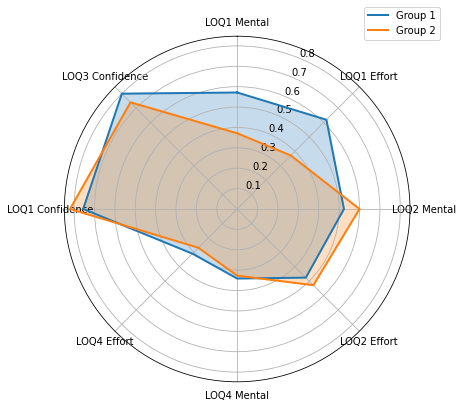

In [3]:
labels_short = [
    'LOQ1 Mental', 'LOQ1 Effort', 'LOQ2 Mental', 'LOQ2 Effort',
    'LOQ4 Mental', 'LOQ4 Effort', 'LOQ1 Confidence', 'LOQ3 Confidence'
]

# Function to create radar chart for group averages
def create_radar_chart(groups_mean, labels, group_names):
    # Set up radar chart
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    # Initialize the radar chart
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Plot data for each group
    for i, group_mean in enumerate(groups_mean):
        values = group_mean.tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, linewidth=2, label=group_names[i])
        ax.fill(angles, values, alpha=0.25)

    # Add labels and customize the radar chart
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    
    # Increase space for the labels
    plt.subplots_adjust(left=0.2, right=0.8, top=0.85, bottom=0.15)
    
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    plt.show()

# Calculate average profile for Group 1 and Group 2
group_1_mean = data[data['Group'] == 1][relevant_columns].mean()
group_2_mean = data[data['Group'] == 2][relevant_columns].mean()

# Plot radar chart with group averages and shorter labels
create_radar_chart([group_1_mean, group_2_mean], labels_short, ['Group 1', 'Group 2'])



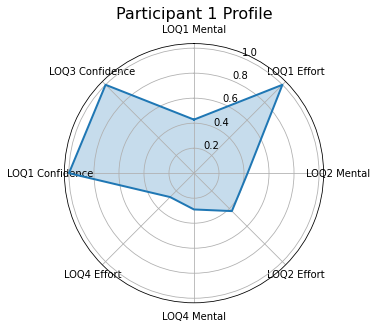

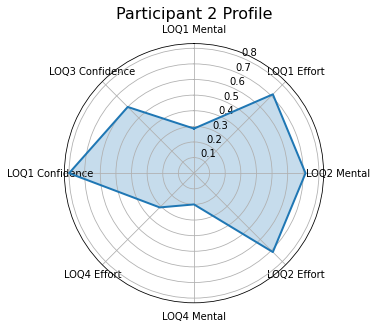

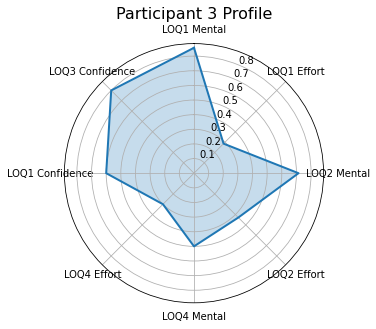

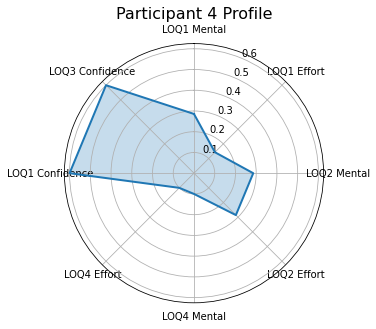

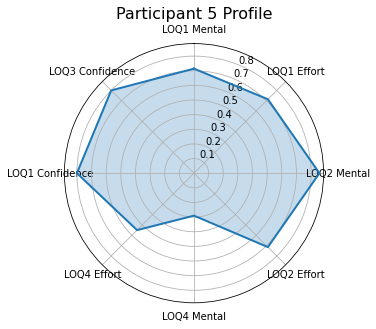

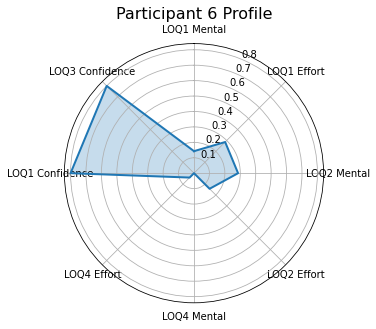

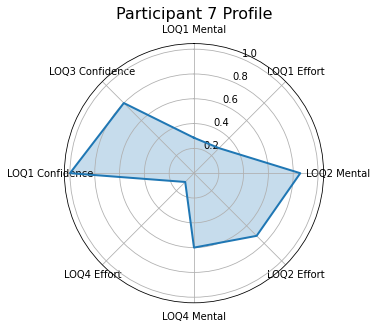

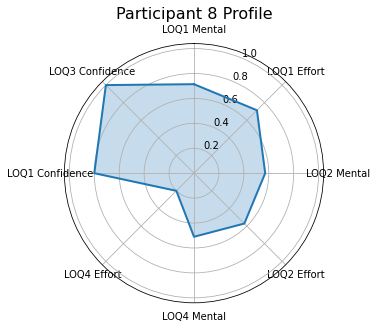

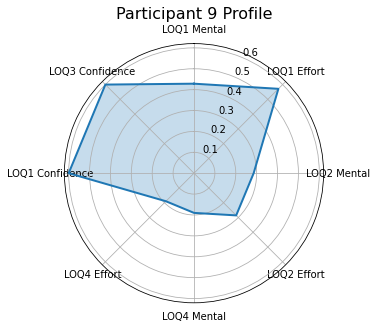

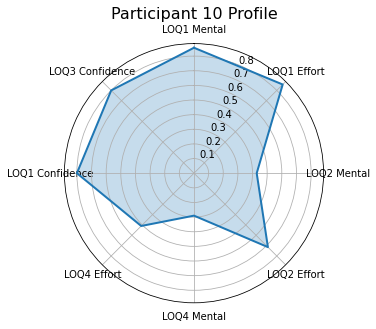

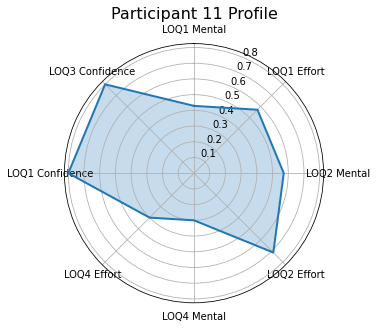

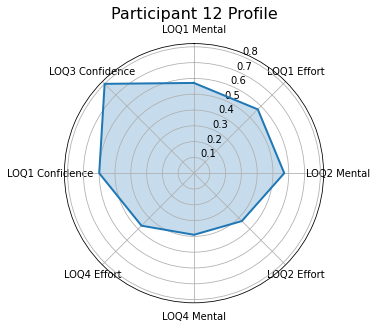

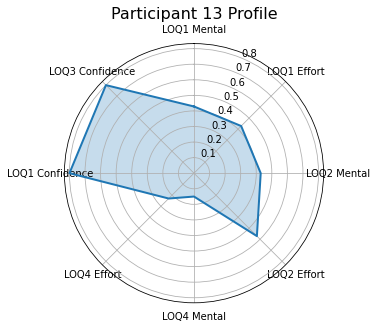

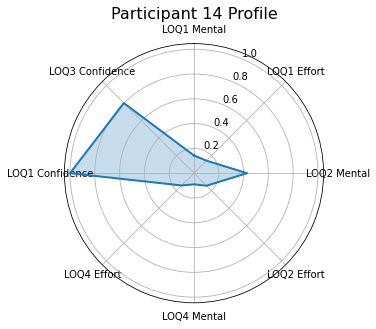

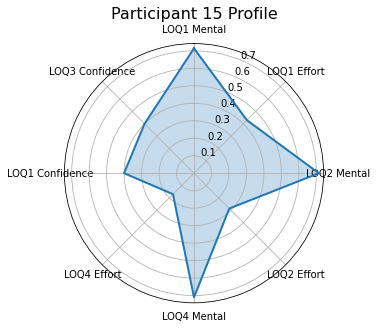

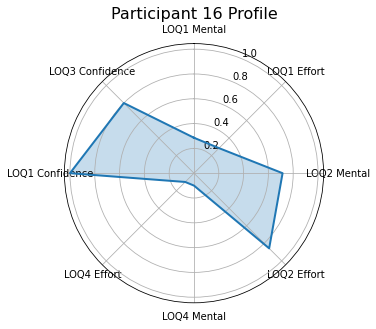

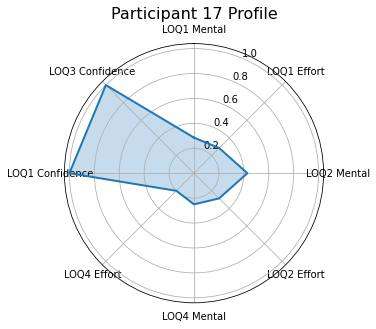

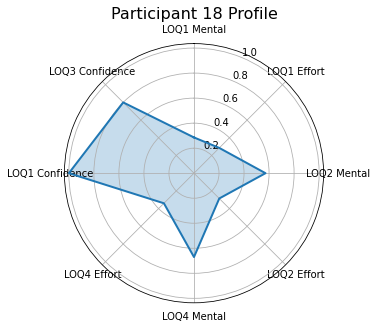

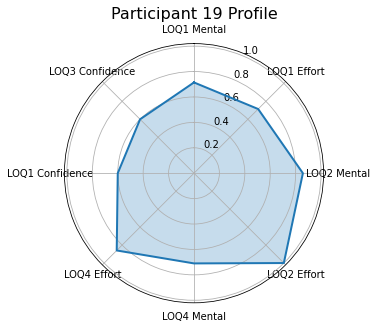

In [4]:
def create_radar_chart_single(participant_data, labels, participant_id):
    # Set up radar chart
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    # Initialize the radar chart
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    # Plot data for the participant
    values = participant_data.tolist()
    values += values[:1]  # Close the loop
    ax.plot(angles, values, linewidth=2, label=f'Participant {participant_id}')
    ax.fill(angles, values, alpha=0.25)

    # Add labels and customize the radar chart
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    
    # Increase space for the labels
    plt.subplots_adjust(left=0.2, right=0.8, top=0.85, bottom=0.15)
    
    # Add a title and show the plot
    plt.title(f'Participant {participant_id} Profile', size=16)
    plt.show()

# Loop through all participants and plot their profiles
for participant_id, participant_data in data[relevant_columns].iterrows():
    create_radar_chart_single(participant_data, labels_short, participant_id + 1) 

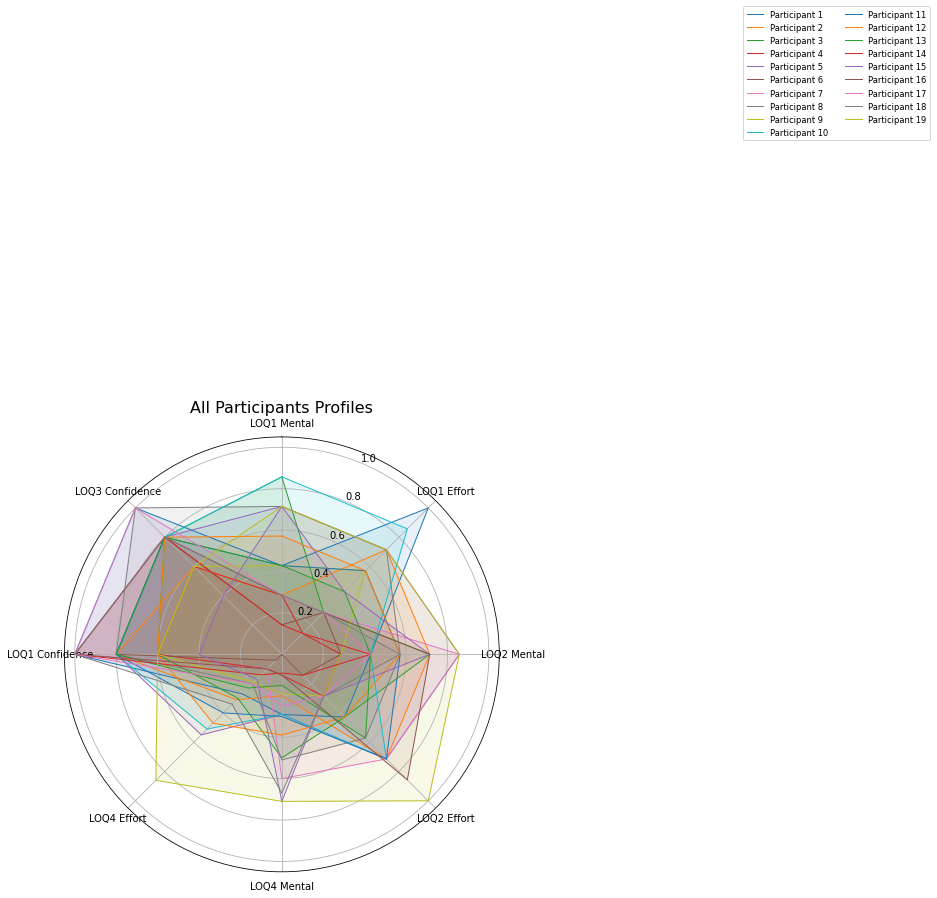

In [7]:
def create_joint_radar_chart(all_participants_data, labels):
    # Set up radar chart
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    # Initialize the radar chart
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Plot data for each participant
    for idx, participant_data in all_participants_data.iterrows():
        values = participant_data.tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, linewidth=1, label=f'Participant {idx + 1}')
        ax.fill(angles, values, alpha=0.1)  # Add a transparent fill to each participant's profile

    # Add labels and customize the radar chart
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    
    # Add title and legend
    plt.title('All Participants Profiles', size=16)
    plt.legend(loc='upper right', bbox_to_anchor=(2, 2), fontsize='small', ncol=2)
    
    plt.show()

# Call the function to create the joint radar chart
create_joint_radar_chart(data[relevant_columns], labels_short)

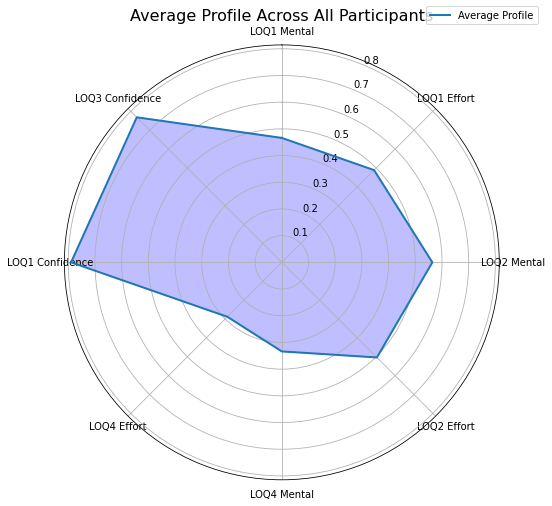

In [8]:
def create_average_radar_chart(average_data, labels):
    # Set up radar chart
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    # Initialize the radar chart
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Plot data for the average profile
    values = average_data.tolist()
    values += values[:1]  # Close the loop
    ax.plot(angles, values, linewidth=2, label='Average Profile')
    ax.fill(angles, values, color='blue', alpha=0.25)

    # Add labels and customize the radar chart
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)

    # Add title and legend
    plt.title('Average Profile Across All Participants', size=16)
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    
    plt.show()

# Calculate the average profile across all participants
average_profile = data[relevant_columns].mean()

# Call the function to create the radar chart for the average profile
create_average_radar_chart(average_profile, labels_short)


In [6]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Define the relevant columns (e.g., LOQ1 and LOQ2 metrics for all factors)
relevant_columns = [
    'LOQ1How mentally demanding was the task?',
    'LOQ1 How hard did you have to work to accomplish your level of performance?',
    'LOQ2 How mentally demanding was the task?',
    'LOQ2 How hard did you have to work to accomplish your level of performance?',
    'LOQ4 How mentally demanding was the task?',
    'LOQ4 How hard did you have to work to accomplish your level of performance?',
    'LOQ 1How confident are you to perform the task on the real powder feeder based on your learning experience?',
    'LOQ 3How confident are you to perform the task on the real powder feeder based on your learning experience?'
]

# Standardize the data (mean=0, variance=1)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[relevant_columns])

# Perform PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_scaled)

# Add the PCA results back to the DataFrame
data['PCA1'] = pca_result[:, 0]
data['PCA2'] = pca_result[:, 1]


Outliers in Group 1:
                Total_Deviation    Group
Participant 15         2.014821  Group 1

Outliers in Group 2:
                Total_Deviation    Group
Participant 19         3.471071  Group 2


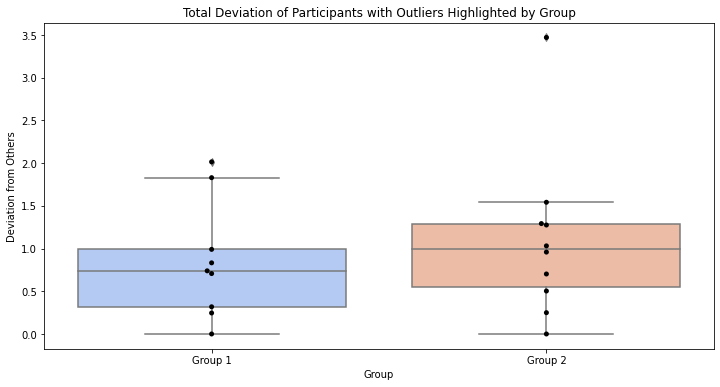

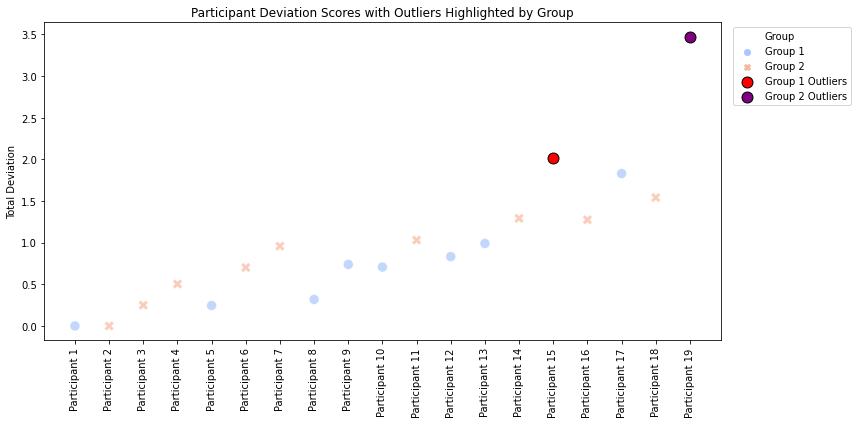

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns for which we want to generate familiarity matrices
relevant_columns = [
    'LOQ1How mentally demanding was the task?',
    'LOQ1 How hard did you have to work to accomplish your level of performance?',
    'LOQ2 How mentally demanding was the task?',
    'LOQ2 How hard did you have to work to accomplish your level of performance?',
    'LOQ4 How mentally demanding was the task?',
    'LOQ4 How hard did you have to work to accomplish your level of performance?',
    'LOQ 1How confident are you to perform the task on the real powder feeder based on your learning experience?',
    'LOQ 3How confident are you to perform the task on the real powder feeder based on your learning experience?'
]

# Initialize a DataFrame to store the total deviation for each participant in both groups
deviation_data = pd.DataFrame(index=[f'Participant {i+1}' for i in range(len(data))], columns=['Total_Deviation', 'Group'])

# Loop through each group separately
for group in [1, 2]:
    group_data = data[data['Group'] == group]
    num_participants = len(group_data)
    participant_labels = [f'Participant {i+1}' for i in group_data.index]

    # Loop through each relevant column and create a familiarity matrix
    for col in relevant_columns:
        # Extract the participant scores for the current column
        participant_scores = group_data[col].values

        # Initialize the familiarity matrix (zeroes initially)
        familiarity_matrix = np.zeros((num_participants, num_participants))

        # Fill in the diagonal and below diagonal with differences (non-absolute)
        for i in range(num_participants):
            for j in range(i + 1):
                if i != j:
                    # Difference between participants
                    familiarity_matrix[i, j] = participant_scores[i] - participant_scores[j]

        # Compute the sum of absolute differences for each participant
        sum_of_differences = np.sum(np.abs(familiarity_matrix), axis=1)
        
        # Update the deviation data
        deviation_data.loc[participant_labels, 'Total_Deviation'] = deviation_data.loc[participant_labels, 'Total_Deviation'].fillna(0) + sum_of_differences

    # Normalize the total deviation by the number of columns for averaging
    deviation_data.loc[participant_labels, 'Total_Deviation'] /= len(relevant_columns)
    deviation_data.loc[participant_labels, 'Group'] = f'Group {group}'

# Convert 'Total_Deviation' to numeric values
deviation_data['Total_Deviation'] = pd.to_numeric(deviation_data['Total_Deviation'])

# Define a function to identify outliers using the IQR method
def identify_outliers(df):
    q1 = df['Total_Deviation'].quantile(0.25)
    q3 = df['Total_Deviation'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df['Total_Deviation'] < lower_bound) | (df['Total_Deviation'] > upper_bound)]
    return outliers

# Identify outliers for Group 1 and Group 2
outliers_group_1 = identify_outliers(deviation_data[deviation_data['Group'] == 'Group 1'])
outliers_group_2 = identify_outliers(deviation_data[deviation_data['Group'] == 'Group 2'])

print("Outliers in Group 1:")
print(outliers_group_1[['Total_Deviation', 'Group']])

print("\nOutliers in Group 2:")
print(outliers_group_2[['Total_Deviation', 'Group']])

# Visualization of deviations using a box plot for each group
plt.figure(figsize=(12, 6))
sns.boxplot(data=deviation_data, x='Group', y='Total_Deviation', palette='coolwarm')
sns.swarmplot(data=deviation_data, x='Group', y='Total_Deviation', color='black', size=5)
plt.title('Total Deviation of Participants with Outliers Highlighted by Group')
plt.ylabel('Deviation from Others')
plt.xlabel('Group')
plt.show()

# Scatter plot with corrected legend parameter
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=deviation_data, x=deviation_data.index, y='Total_Deviation', hue='Group',
    style='Group', s=100, alpha=0.7, palette='coolwarm', legend='brief'  # Use 'brief' or 'full'
)
# Highlight the outliers in red for better visibility
plt.scatter(outliers_group_1.index, outliers_group_1['Total_Deviation'], color='red', label='Group 1 Outliers', s=120, edgecolors='black')
plt.scatter(outliers_group_2.index, outliers_group_2['Total_Deviation'], color='purple', label='Group 2 Outliers', s=120, edgecolors='black')
plt.title('Participant Deviation Scores with Outliers Highlighted by Group')
plt.ylabel('Total Deviation')
plt.xticks(rotation=90)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()


Outliers in Group 1:
               Total_Deviation
Participant 8         2.014821

Outliers in Group 2:
                Total_Deviation
Participant 10         3.471071


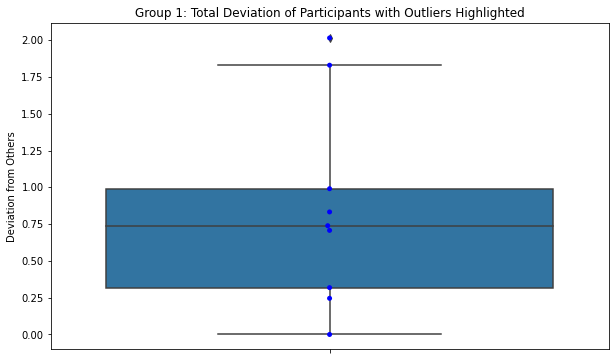

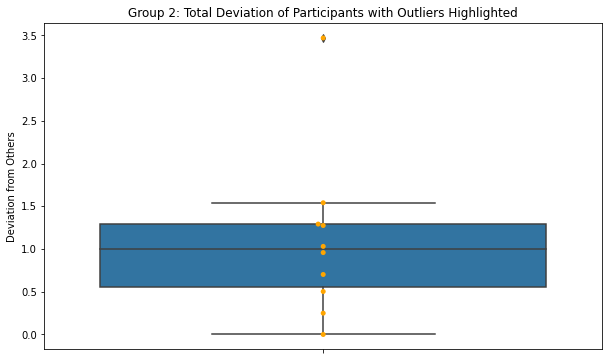

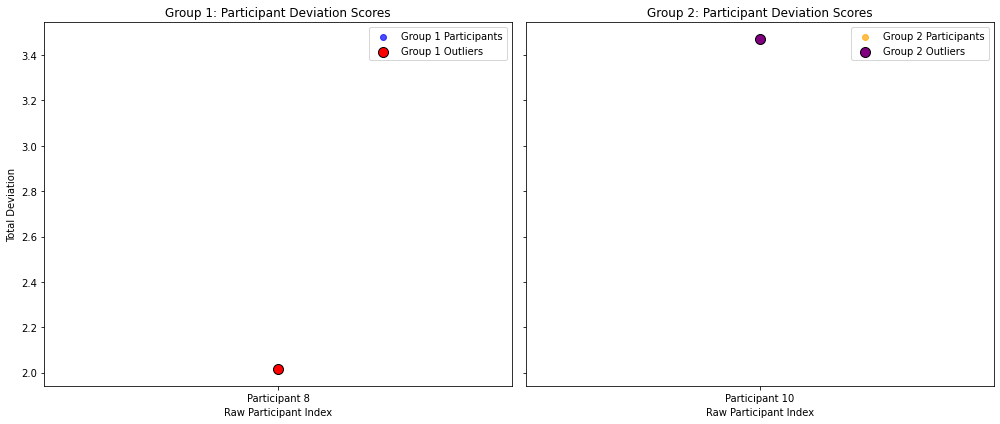

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns for which we want to generate familiarity matrices
relevant_columns = [
    'LOQ1How mentally demanding was the task?',
    'LOQ1 How hard did you have to work to accomplish your level of performance?',
    'LOQ2 How mentally demanding was the task?',
    'LOQ2 How hard did you have to work to accomplish your level of performance?',
    'LOQ4 How mentally demanding was the task?',
    'LOQ4 How hard did you have to work to accomplish your level of performance?',
    'LOQ 1How confident are you to perform the task on the real powder feeder based on your learning experience?',
    'LOQ 3How confident are you to perform the task on the real powder feeder based on your learning experience?'
]

# Initialize a function to compute deviation for a group
def compute_group_deviation(group_data, relevant_columns):
    # Initialize a DataFrame to store the total deviation for each participant in this group
    num_participants = len(group_data)
    deviation_data = pd.DataFrame(index=[f'Participant {i+1}' for i in range(num_participants)], columns=['Total_Deviation'])
    deviation_data['Total_Deviation'] = 0  # Initialize to zero

    # Loop through each relevant column and create a familiarity matrix for the group
    for col in relevant_columns:
        # Extract the participant scores for the current column
        participant_scores = group_data[col].values

        # Initialize the familiarity matrix (zeroes initially)
        familiarity_matrix = np.zeros((num_participants, num_participants))

        # Fill in the diagonal and below diagonal with differences (non-absolute)
        for i in range(num_participants):
            for j in range(i + 1):
                if i != j:
                    # Difference between participants
                    familiarity_matrix[i, j] = participant_scores[i] - participant_scores[j]

        # Compute the sum of absolute differences for each participant
        sum_of_differences = np.sum(np.abs(familiarity_matrix), axis=1)

        # Add the sum of differences to the deviation_data DataFrame
        deviation_data['Total_Deviation'] += sum_of_differences

    # Normalize the total deviation by the number of columns for averaging
    deviation_data['Total_Deviation'] /= len(relevant_columns)

    return deviation_data

# Identify outliers using the IQR method
def identify_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Split the data by group
group_1_data = data[data['Group'] == 1].reset_index(drop=True)
group_2_data = data[data['Group'] == 2].reset_index(drop=True)

# Compute deviation for Group 1
group_1_deviation = compute_group_deviation(group_1_data, relevant_columns)
outliers_group_1 = identify_outliers(group_1_deviation, 'Total_Deviation')

# Compute deviation for Group 2
group_2_deviation = compute_group_deviation(group_2_data, relevant_columns)
outliers_group_2 = identify_outliers(group_2_deviation, 'Total_Deviation')

# Print outliers
print("Outliers in Group 1:")
print(outliers_group_1)

print("\nOutliers in Group 2:")
print(outliers_group_2)

# Visualization for Group 1
plt.figure(figsize=(10, 6))
sns.boxplot(data=group_1_deviation, y='Total_Deviation')
sns.swarmplot(data=group_1_deviation, y='Total_Deviation', color='blue', size=5)
plt.title('Group 1: Total Deviation of Participants with Outliers Highlighted')
plt.ylabel('Deviation from Others')
plt.show()

# Visualization for Group 2
plt.figure(figsize=(10, 6))
sns.boxplot(data=group_2_deviation, y='Total_Deviation')
sns.swarmplot(data=group_2_deviation, y='Total_Deviation', color='orange', size=5)
plt.title('Group 2: Total Deviation of Participants with Outliers Highlighted')
plt.ylabel('Deviation from Others')
plt.show()

import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Use raw indices for x-axis
x_vals_group_1 = group_1_data.index
x_vals_group_2 = group_2_data.index

# Plot for Group 1
axes[0].scatter(x_vals_group_1, group_1_deviation['Total_Deviation'], alpha=0.7, color='blue', label='Group 1 Participants')
axes[0].scatter(outliers_group_1.index, outliers_group_1['Total_Deviation'], color='red', label='Group 1 Outliers', s=100, edgecolors='black')
axes[0].set_title('Group 1: Participant Deviation Scores')
axes[0].set_ylabel('Total Deviation')
axes[0].set_xlabel('Raw Participant Index')
axes[0].legend()

# Plot for Group 2
axes[1].scatter(x_vals_group_2, group_2_deviation['Total_Deviation'], alpha=0.7, color='orange', label='Group 2 Participants')
axes[1].scatter(outliers_group_2.index, outliers_group_2['Total_Deviation'], color='purple', label='Group 2 Outliers', s=100, edgecolors='black')
axes[1].set_title('Group 2: Participant Deviation Scores')
axes[1].set_xlabel('Raw Participant Index')
axes[1].legend()

# Adjust layout for better visualization
plt.tight_layout()
plt.show()
